In [1]:
import pandas as pd
import numpy as np
import mlflow
import matplotlib.pyplot as plt


In [2]:
from prophet import Prophet


In [ ]:
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("http://127.0.0.1:5000")

client = MlflowClient()

# Get the old experiment and delete it
exp = client.get_experiment_by_name("Electricity_Load_Forecasting")
if exp:
    client.delete_experiment(exp.experiment_id)


RestException: RESOURCE_DOES_NOT_EXIST: Could not find experiment with ID 894390893589220535

In [3]:
df=pd.read_csv(r"C:\Users\Top Prix\OneDrive\New folder\Thesis_Project\data\feature_engineered_data.csv")

In [ ]:

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Electricity_Demand_Forecasting")


KeyboardInterrupt: 

In [4]:
df['timestamp']=pd.to_datetime(df['timestamp'])
df=df.set_index('timestamp')

In [7]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import itertools
import time

warnings.filterwarnings("ignore")

# ============================================================
# 1) DATA
# ============================================================
target_col = "load"
y = df[target_col]

# Full training period (before test set)
full_train = y.loc[: "2025-06-30 23:00"].dropna()

# Internal split for grid search ONLY
# Train: Jan 2023 – May 2025 | Val: June 2025
internal_train = full_train.loc[: "2025-05-31 23:00"].dropna()
internal_val = full_train.loc["2025-06-01 00:00": "2025-06-30 23:00"].dropna()

train_df = internal_train.reset_index()
train_df.columns = ["ds", "y"]

val_df = pd.DataFrame({"ds": internal_val.index})

print(f"Internal train: {len(internal_train)} rows | Internal val: {len(internal_val)} rows")

# ============================================================
# 2) GRID SEARCH ON INTERNAL VALIDATION (June 2025)
# ============================================================
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'daily_seasonality': [4, 8, 12, 15],
    'yearly_seasonality': [10, 15, 20],
    'changepoint_range': [0.8, 0.9, 0.95],
    'n_changepoints': [15, 25, 50],
}

all_params = [dict(zip(param_grid.keys(), v)) 
              for v in itertools.product(*param_grid.values())]

print(f"Total combinations: {len(all_params)}")
print("=" * 60)

results = []
start_time = time.time()

for combo_idx, params in enumerate(all_params):
    try:
        model = Prophet(
            growth="linear",
            yearly_seasonality=params['yearly_seasonality'],
            weekly_seasonality=True,
            daily_seasonality=params['daily_seasonality'],
            seasonality_mode="additive",
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            holidays=None,
            n_changepoints=params['n_changepoints'],
            changepoint_range=params['changepoint_range'],
        )
        
        model.fit(train_df)
        forecast = model.predict(val_df)
        pred = forecast["yhat"].values
        
        mae = np.mean(np.abs(internal_val.values - pred))
        rmse = np.sqrt(np.mean((internal_val.values - pred) ** 2))
        mape = np.mean(np.abs((internal_val.values - pred) / internal_val.values)) * 100
        
        results.append({
            'combo_idx': combo_idx,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            **params,
        })
        
        if (combo_idx + 1) % 50 == 0:
            elapsed = time.time() - start_time
            print(f"[{combo_idx+1}/{len(all_params)}] Best MAPE so far: {min(r['MAPE'] for r in results):.2f}% | {elapsed:.0f}s")
            
    except Exception as e:
        print(f"[{combo_idx+1}] FAILED: {e}")
        continue

# Save and rank
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('MAPE')
results_df.to_csv("prophet_gridsearch_train_only.csv", index=False)

print("\n" + "=" * 60)
print("TOP 5 CONFIGURATIONS (from June 2025 validation)")
print("=" * 60)
print(results_df.head(5)[['MAPE', 'MAE', 'RMSE', 'changepoint_prior_scale', 
                            'seasonality_prior_scale', 'daily_seasonality', 
                            'yearly_seasonality', 'changepoint_range', 'n_changepoints']])

best = results_df.iloc[0]
print(f"\nBEST PARAMS: MAPE={best['MAPE']:.2f}% on June 2025 validation")

# ============================================================
# 3) FULL WALK-FORWARD ON TEST SET (July–December 2025)
# ============================================================
print("\nRunning walk-forward on test set with best params...")

origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")
preds_prophet = []
actuals_prophet = []
monthly_metrics = []

for i, origin in enumerate(origins):
    month_end = origin + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23)
    train_block = y.loc[: origin - pd.Timedelta(hours=1)].dropna()
    actual_month = y.loc[origin:month_end].dropna()
    
    if len(actual_month) == 0:
        continue
        
    train_p = train_block.reset_index()
    train_p.columns = ["ds", "y"]
    
    model = Prophet(
        growth="linear",
        yearly_seasonality=int(best['yearly_seasonality']),
        weekly_seasonality=True,
        daily_seasonality=int(best['daily_seasonality']),
        seasonality_mode="additive",
        changepoint_prior_scale=best['changepoint_prior_scale'],
        seasonality_prior_scale=best['seasonality_prior_scale'],
        holidays=None,
        n_changepoints=int(best['n_changepoints']),
        changepoint_range=best['changepoint_range'],
    )
    
    model.fit(train_p)
    future = pd.DataFrame({"ds": actual_month.index})
    forecast = model.predict(future)
    pred_month = pd.Series(forecast["yhat"].values, index=actual_month.index)
    
    preds_prophet.append(pred_month)
    actuals_prophet.append(actual_month)
    
    mae_m = np.mean(np.abs(actual_month - pred_month))
    rmse_m = np.sqrt(np.mean((actual_month - pred_month) ** 2))
    mape_m = np.mean(np.abs((actual_month - pred_month) / actual_month)) * 100
    
    monthly_metrics.append({
        "origin_month": origin.strftime("%Y-%m"),
        "n_hours": len(actual_month),
        "MAE": mae_m,
        "RMSE": rmse_m,
        "MAPE": mape_m
    })

# Overall test metrics
pred_prophet = pd.concat(preds_prophet).sort_index()
actual_prophet = pd.concat(actuals_prophet).sort_index()

mae = np.mean(np.abs(actual_prophet - pred_prophet))
rmse = np.sqrt(np.mean((actual_prophet - pred_prophet) ** 2))
mape = np.mean(np.abs((actual_prophet - pred_prophet) / actual_prophet)) * 100

print(f"\nFinal Walk-Forward Results (July–December 2025)")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

monthly_df = pd.DataFrame(monthly_metrics)
print("\nMonthly breakdown:")
print(monthly_df)

monthly_df.to_csv("prophet_best_walkforward_monthly.csv", index=False)

# Plot
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(actual_prophet.index, actual_prophet.values, label="Actual", linewidth=1.0)
ax.plot(pred_prophet.index, pred_prophet.values, label="Best Prophet", linewidth=1.0, alpha=0.85)
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title(f"Prophet Grid-Search Best — Walk-Forward MAPE {mape:.2f}%")
ax.legend()
plt.tight_layout()
plt.savefig("prophet_best_walkforward.png", dpi=300)
plt.show()

Internal train: 21000 rows | Internal val: 720 rows
Total combinations: 2160


17:01:45 - cmdstanpy - INFO - Chain [1] start processing
17:01:53 - cmdstanpy - INFO - Chain [1] done processing
17:01:55 - cmdstanpy - INFO - Chain [1] start processing
17:02:00 - cmdstanpy - INFO - Chain [1] done processing
17:02:02 - cmdstanpy - INFO - Chain [1] start processing
17:02:07 - cmdstanpy - INFO - Chain [1] done processing
17:02:08 - cmdstanpy - INFO - Chain [1] start processing
17:02:13 - cmdstanpy - INFO - Chain [1] done processing
17:02:15 - cmdstanpy - INFO - Chain [1] start processing
17:02:20 - cmdstanpy - INFO - Chain [1] done processing
17:02:22 - cmdstanpy - INFO - Chain [1] start processing
17:02:31 - cmdstanpy - INFO - Chain [1] done processing
17:02:33 - cmdstanpy - INFO - Chain [1] start processing
17:02:37 - cmdstanpy - INFO - Chain [1] done processing
17:02:39 - cmdstanpy - INFO - Chain [1] start processing
17:02:46 - cmdstanpy - INFO - Chain [1] done processing
17:02:48 - cmdstanpy - INFO - Chain [1] start processing
17:02:54 - cmdstanpy - INFO - Chain [1]

[50/2160] Best MAPE so far: 16.89% | 464s


17:09:30 - cmdstanpy - INFO - Chain [1] start processing
17:09:35 - cmdstanpy - INFO - Chain [1] done processing
17:09:38 - cmdstanpy - INFO - Chain [1] start processing
17:09:50 - cmdstanpy - INFO - Chain [1] done processing
17:09:52 - cmdstanpy - INFO - Chain [1] start processing
17:09:59 - cmdstanpy - INFO - Chain [1] done processing
17:10:01 - cmdstanpy - INFO - Chain [1] start processing
17:10:11 - cmdstanpy - INFO - Chain [1] done processing
17:10:13 - cmdstanpy - INFO - Chain [1] start processing
17:10:23 - cmdstanpy - INFO - Chain [1] done processing
17:10:25 - cmdstanpy - INFO - Chain [1] start processing
17:10:34 - cmdstanpy - INFO - Chain [1] done processing
17:10:36 - cmdstanpy - INFO - Chain [1] start processing
17:10:44 - cmdstanpy - INFO - Chain [1] done processing
17:10:46 - cmdstanpy - INFO - Chain [1] start processing
17:10:56 - cmdstanpy - INFO - Chain [1] done processing
17:10:58 - cmdstanpy - INFO - Chain [1] start processing
17:11:05 - cmdstanpy - INFO - Chain [1]

KeyboardInterrupt: 


Origin 1/6 — 2025-07-01
  Train rows: 21720 | Test rows: 744


21:53:54 - cmdstanpy - INFO - Chain [1] start processing
21:54:27 - cmdstanpy - INFO - Chain [1] done processing


  Done — 744 hours forecasted
  Monthly MAE=4098.17 | RMSE=4546.96 | MAPE=30.98%

Origin 2/6 — 2025-08-01
  Train rows: 22464 | Test rows: 744


21:54:29 - cmdstanpy - INFO - Chain [1] start processing
21:54:54 - cmdstanpy - INFO - Chain [1] done processing


  Done — 744 hours forecasted
  Monthly MAE=2341.89 | RMSE=2833.91 | MAPE=17.20%

Origin 3/6 — 2025-09-01
  Train rows: 23208 | Test rows: 720


...

  Done — 744 hours forecasted
  Monthly MAE=1594.21 | RMSE=1725.92 | MAPE=20.66%

Origin 5/6 — 2025-11-01
  Train rows: 24672 | Test rows: 720


21:56:05 - cmdstanpy - INFO - Chain [1] start processing
21:56:33 - cmdstanpy - INFO - Chain [1] done processing


  Done — 720 hours forecasted
  Monthly MAE=1005.69 | RMSE=1193.94 | MAPE=12.23%

Origin 6/6 — 2025-12-01
  Train rows: 25392 | Test rows: 744


21:56:35 - cmdstanpy - INFO - Chain [1] start processing
21:57:13 - cmdstanpy - INFO - Chain [1] done processing


  Done — 744 hours forecasted
  Monthly MAE=538.28 | RMSE=660.62 | MAPE=6.12%

Prophet Walk-Forward Results
MAE  = 1802.37 MW
RMSE = 2442.16 MW
MAPE = 16.47 %

Monthly metrics by origin:
  origin_month  n_hours          MAE         RMSE       MAPE
0      2025-07      744  4098.171954  4546.964239  30.983265
1      2025-08      744  2341.890536  2833.906835  17.195659
2      2025-09      720  1190.560370  1401.034829  11.309412
3      2025-10      744  1594.212233  1725.917383  20.655551
4      2025-11      720  1005.688273  1193.936580  12.226100
5      2025-12      744   538.277191   660.618338   6.123919


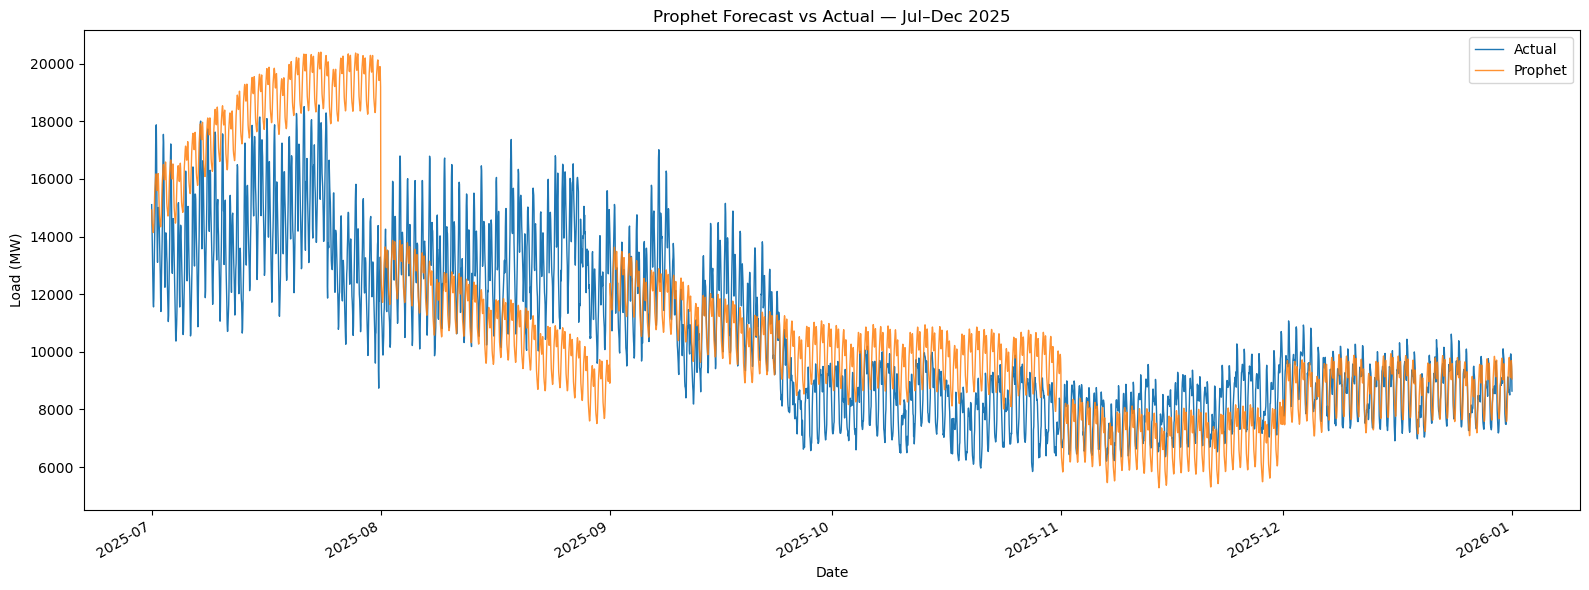

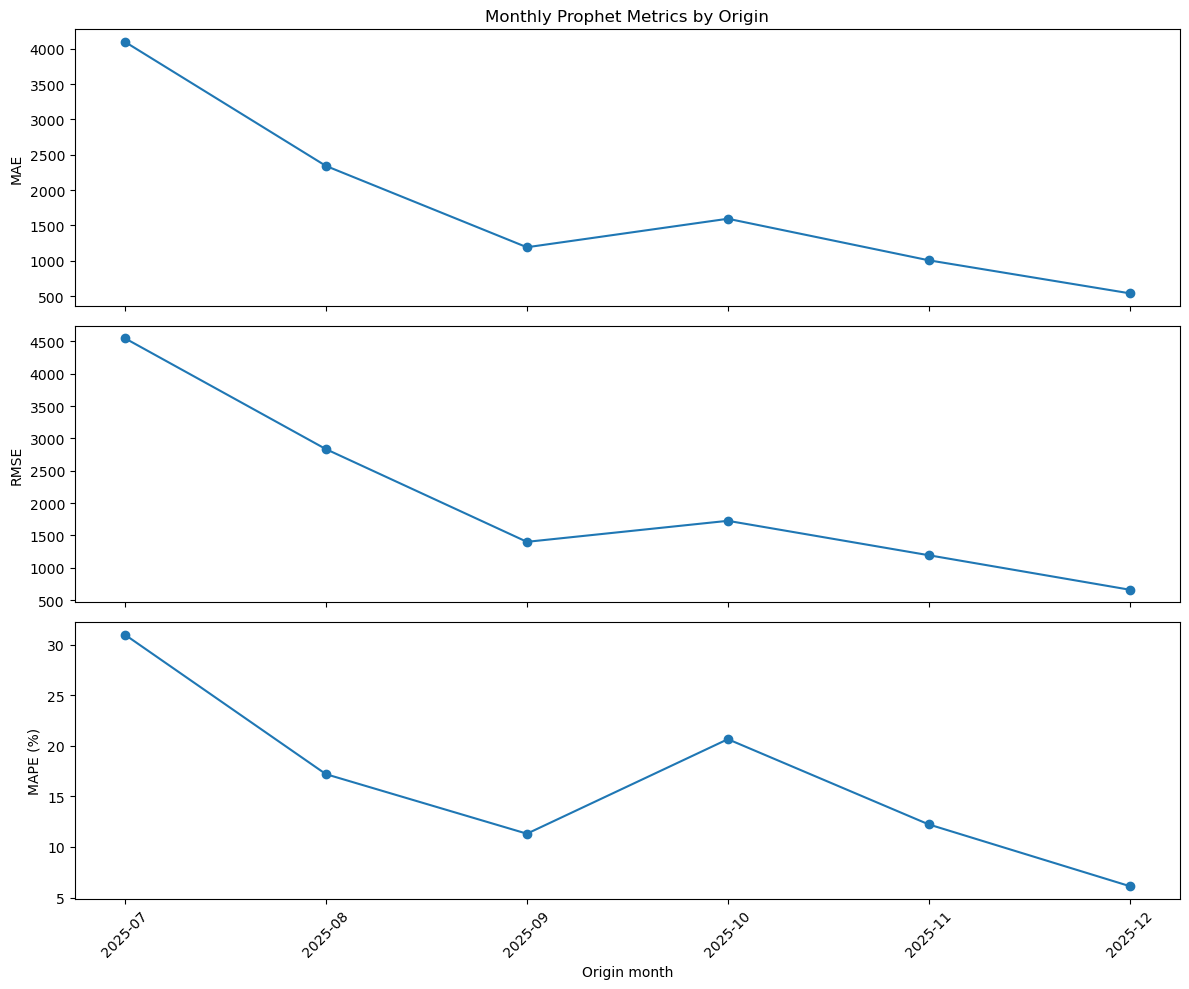

🏃 View run Prophet_walkforward_monthly_final at: http://127.0.0.1:5000/#/experiments/531580567308328190/runs/f59b1928e627441696af4123e4976fc4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/531580567308328190


In [7]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

from prophet import Prophet

warnings.filterwarnings("ignore")

# ============================================================
# 1) SETTINGS
# ============================================================
target_col = "load"
y = df[target_col]

origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

preds_prophet = []
actuals_prophet = []
monthly_metrics = []

# ============================================================
# 2) MONTHLY WALK-FORWARD LOOP
# ============================================================
for i, origin in enumerate(origins):
    print(f"\n{'='*60}")
    print(f"Origin {i+1}/{len(origins)} — {origin.date()}")

    month_end = origin + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23)

    train = y.loc[: origin - pd.Timedelta(hours=1)].dropna()
    actual_month = y.loc[origin:month_end].dropna()

    if len(actual_month) == 0:
        print("  Skipped — empty test block")
        continue

    print(f"  Train rows: {len(train)} | Test rows: {len(actual_month)}")

    train_prophet = train.reset_index()
    train_prophet.columns = ["ds", "y"]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True,
        seasonality_mode="additive"
    )

    model.fit(train_prophet)

    future = pd.DataFrame({"ds": actual_month.index})
    forecast = model.predict(future)

    pred_month = pd.Series(forecast["yhat"].values, index=actual_month.index)

    preds_prophet.append(pred_month)
    actuals_prophet.append(actual_month)

    # -------------------------
    # monthly metrics
    # -------------------------
    mae_m = np.mean(np.abs(actual_month - pred_month))
    rmse_m = np.sqrt(np.mean((actual_month - pred_month) ** 2))
    mape_m = np.mean(np.abs((actual_month - pred_month) / actual_month)) * 100

    monthly_metrics.append({
        "origin_month": origin.strftime("%Y-%m"),
        "n_hours": len(actual_month),
        "MAE": mae_m,
        "RMSE": rmse_m,
        "MAPE": mape_m
    })

    print(f"  Done — {len(actual_month)} hours forecasted")
    print(f"  Monthly MAE={mae_m:.2f} | RMSE={rmse_m:.2f} | MAPE={mape_m:.2f}%")

# ============================================================
# 3) OVERALL METRICS
# ============================================================
pred_prophet = pd.concat(preds_prophet).sort_index()
actual_prophet = pd.concat(actuals_prophet).sort_index()

mae = np.mean(np.abs(actual_prophet - pred_prophet))
rmse = np.sqrt(np.mean((actual_prophet - pred_prophet) ** 2))
mape = np.mean(np.abs((actual_prophet - pred_prophet) / actual_prophet)) * 100

print(f"\nProphet Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ============================================================
# 4) MONTHLY METRICS TABLE
# ============================================================
monthly_metrics_df = pd.DataFrame(monthly_metrics)

print("\nMonthly metrics by origin:")
print(monthly_metrics_df)

# ============================================================
# 5) SAVE TABLES
# ============================================================
monthly_metrics_df.to_csv("prophet_monthly_metrics.csv", index=False)

pred_vs_actual_df = pd.DataFrame({
    "actual": actual_prophet,
    "predicted": pred_prophet
})
pred_vs_actual_df.to_csv("prophet_walkforward_predictions.csv")

# ============================================================
# 6) PLOT: TEST ACTUAL VS FORECAST ONLY
# ============================================================
fig_forecast, ax = plt.subplots(figsize=(16, 6))

ax.plot(actual_prophet.index, actual_prophet.values, label="Actual", linewidth=1.0)
ax.plot(pred_prophet.index, pred_prophet.values, label="Prophet", linewidth=1.0, alpha=0.85)

ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("Prophet Forecast vs Actual — Jul–Dec 2025")
ax.legend()

fig_forecast.autofmt_xdate()
plt.tight_layout()
plt.show()

# ============================================================
# 7) OPTIONAL: MONTHLY METRIC PLOT
# ============================================================
fig_metrics, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(monthly_metrics_df["origin_month"], monthly_metrics_df["MAE"], marker="o")
axes[0].set_ylabel("MAE")
axes[0].set_title("Monthly Prophet Metrics by Origin")

axes[1].plot(monthly_metrics_df["origin_month"], monthly_metrics_df["RMSE"], marker="o")
axes[1].set_ylabel("RMSE")

axes[2].plot(monthly_metrics_df["origin_month"], monthly_metrics_df["MAPE"], marker="o")
axes[2].set_ylabel("MAPE (%)")
axes[2].set_xlabel("Origin month")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 8) MLFLOW LOGGING
# ============================================================
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Electricity_Demand_Forecasting")

with mlflow.start_run(run_name="Prophet_walkforward_monthly_final"):
    mlflow.log_param("model", "Prophet")
    mlflow.log_param("yearly_seasonality", True)
    mlflow.log_param("weekly_seasonality", True)
    mlflow.log_param("daily_seasonality", True)
    mlflow.log_param("seasonality_mode", "additive")
    mlflow.log_param("refit_frequency", "monthly")
    mlflow.log_param("forecast_horizon", "monthly_block")
    mlflow.log_param("changepoint_prior_scale", 0.05)   # Prophet default
    mlflow.log_param("seasonality_prior_scale", 10.0)   # Prophet default
    mlflow.log_param("holidays_prior_scale", 10.0)      # Prophet default
    mlflow.log_param("n_changepoints", 25)              # Prophet default

    mlflow.log_metric("MAE", float(mae))
    mlflow.log_metric("RMSE", float(rmse))
    mlflow.log_metric("MAPE", float(mape))

    mlflow.log_artifact("prophet_monthly_metrics.csv")
    mlflow.log_artifact("prophet_walkforward_predictions.csv")

    fig_forecast.savefig("prophet_forecast.png")
    mlflow.log_artifact("prophet_forecast.png")


Origin 1/6 — 2025-07-01


18:33:54 - cmdstanpy - INFO - Chain [1] start processing
18:34:26 - cmdstanpy - INFO - Chain [1] done processing


  Done — 744 hours forecasted

Origin 2/6 — 2025-08-01


18:34:28 - cmdstanpy - INFO - Chain [1] start processing
18:34:49 - cmdstanpy - INFO - Chain [1] done processing


  Done — 744 hours forecasted

Origin 3/6 — 2025-09-01


...

  Done — 744 hours forecasted

Origin 5/6 — 2025-11-01


18:35:40 - cmdstanpy - INFO - Chain [1] start processing
18:36:10 - cmdstanpy - INFO - Chain [1] done processing


  Done — 720 hours forecasted

Origin 6/6 — 2025-12-01


18:36:12 - cmdstanpy - INFO - Chain [1] start processing
18:36:41 - cmdstanpy - INFO - Chain [1] done processing


  Done — 744 hours forecasted

Prophet Walk-Forward Results
MAE  = 1802.53 MW
RMSE = 2448.31 MW
MAPE = 17.05 %


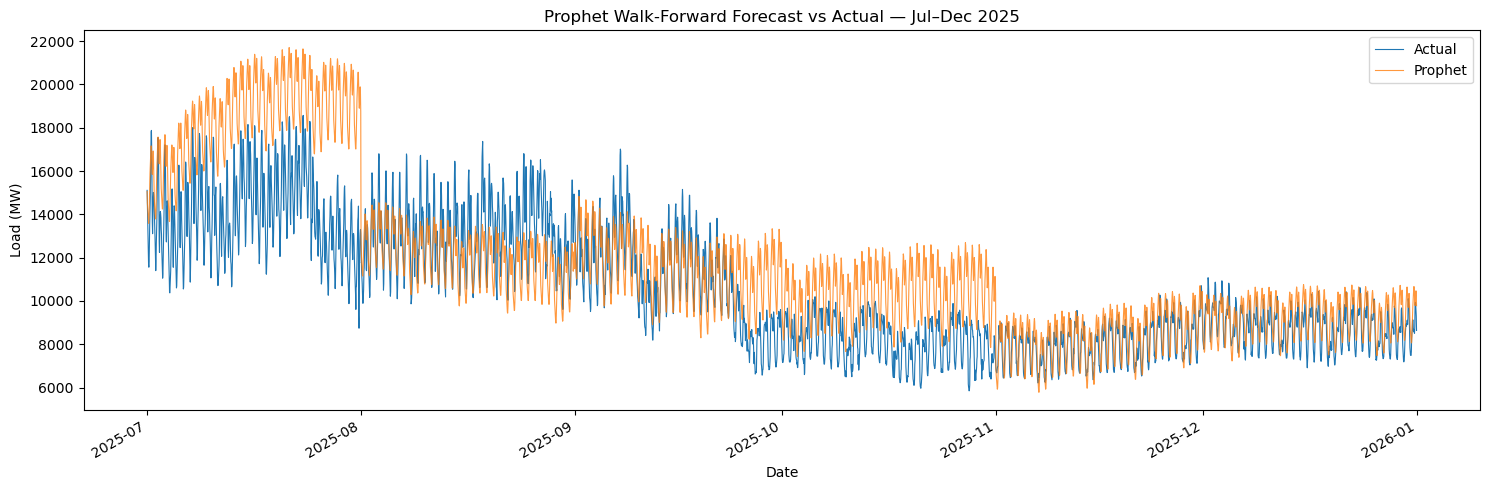

🏃 View run Prophet_walkforward at: http://127.0.0.1:5000/#/experiments/4/runs/52b2c800a2544605ac65de2d1016b031
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


In [7]:

# ── target series (must have DatetimeIndex) ───────────────────
y = df['load']

# ── walk-forward loop ─────────────────────────────────────────
origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

preds_prophet   = []
actuals_prophet = []

for i, origin in enumerate(origins):
    print(f"\n{'='*50}")
    print(f"Origin {i+1}/6 — {origin.date()}")

    month_end    = origin + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23)
    train        = y.loc[: origin - pd.Timedelta(hours=1)]
    actual_month = y.loc[origin : month_end]

    train_prophet = train.reset_index()
    train_prophet.columns = ['ds', 'y']

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True,
        seasonality_mode='multiplicative'
    )

    model.fit(train_prophet)

    future = pd.DataFrame({'ds': actual_month.index})
    forecast = model.predict(future)

    pred_month = pd.Series(forecast['yhat'].values, index=actual_month.index)

    preds_prophet.append(pred_month)
    actuals_prophet.append(actual_month)
    print(f"  Done — {len(actual_month)} hours forecasted")

# ── metrics ───────────────────────────────────────────────────
pred_prophet   = pd.concat(preds_prophet).sort_index()
actual_prophet = pd.concat(actuals_prophet).sort_index()

mae  = np.mean(np.abs(actual_prophet - pred_prophet))
rmse = np.sqrt(np.mean((actual_prophet - pred_prophet)**2))
mape = np.mean(np.abs((actual_prophet - pred_prophet) / actual_prophet)) * 100

print(f"\nProphet Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ── plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(actual_prophet.index, actual_prophet.values, label='Actual', linewidth=0.8)
ax.plot(pred_prophet.index, pred_prophet.values, label='Prophet', linewidth=0.8, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Load (MW)')
ax.set_title('Prophet Walk-Forward Forecast vs Actual — Jul–Dec 2025')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# ── mlflow logging ────────────────────────────────────────────
with mlflow.start_run(run_name="Prophet_walkforward"):
    mlflow.log_param("model", "Prophet")
    mlflow.log_param("yearly_seasonality", True)
    mlflow.log_param("weekly_seasonality", True)
    mlflow.log_param("daily_seasonality", True)
    mlflow.log_param("seasonality_mode", "multiplicative")
    mlflow.log_param("refit_frequency", "monthly")
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAPE", mape)
    fig.savefig("prophet_forecast.png")
    mlflow.log_artifact("prophet_forecast.png")